In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

# Weather - Include Minutes also

In [2]:
df = pd.read_csv(r'Solcast\SDPIPL_Hist_Weather.csv')
df.head(10)

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,period_end,period
0,28,0,0,80.7,224,1.3,2024-10-01T00:10:00+00:00,PT10M
1,28,0,0,80.6,223,1.3,2024-10-01T00:20:00+00:00,PT10M
2,28,0,0,80.4,223,1.4,2024-10-01T00:30:00+00:00,PT10M
3,28,0,0,80.3,222,1.4,2024-10-01T00:40:00+00:00,PT10M
4,28,0,0,80.1,221,1.5,2024-10-01T00:50:00+00:00,PT10M
5,28,0,0,79.9,220,1.5,2024-10-01T01:00:00+00:00,PT10M
6,28,6,6,79.6,220,1.6,2024-10-01T01:10:00+00:00,PT10M
7,28,19,18,79.1,220,1.7,2024-10-01T01:20:00+00:00,PT10M
8,28,32,31,78.5,221,1.9,2024-10-01T01:30:00+00:00,PT10M
9,29,47,46,78.0,221,2.0,2024-10-01T01:40:00+00:00,PT10M


In [3]:
df.dtypes

air_temp                int64
ghi                     int64
gti                     int64
relative_humidity     float64
wind_direction_10m      int64
wind_speed_10m        float64
period_end             object
period                 object
dtype: object

In [4]:
# convert to datetime

df['period_end'] = pd.to_datetime(df['period_end'])
df.head()

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,period_end,period
0,28,0,0,80.7,224,1.3,2024-10-01 00:10:00+00:00,PT10M
1,28,0,0,80.6,223,1.3,2024-10-01 00:20:00+00:00,PT10M
2,28,0,0,80.4,223,1.4,2024-10-01 00:30:00+00:00,PT10M
3,28,0,0,80.3,222,1.4,2024-10-01 00:40:00+00:00,PT10M
4,28,0,0,80.1,221,1.5,2024-10-01 00:50:00+00:00,PT10M


In [5]:
# Feature Formatting

df['hour'] = df['period_end'].dt.hour
df['month'] = df['period_end'].dt.month
df['day'] = df['period_end'].dt.day
df['weekday'] = df['period_end'].dt.weekday
df['is_weekend'] = df['weekday'] >= 5

df.head(10)

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,period_end,period,hour,month,day,weekday,is_weekend
0,28,0,0,80.7,224,1.3,2024-10-01 00:10:00+00:00,PT10M,0,10,1,1,False
1,28,0,0,80.6,223,1.3,2024-10-01 00:20:00+00:00,PT10M,0,10,1,1,False
2,28,0,0,80.4,223,1.4,2024-10-01 00:30:00+00:00,PT10M,0,10,1,1,False
3,28,0,0,80.3,222,1.4,2024-10-01 00:40:00+00:00,PT10M,0,10,1,1,False
4,28,0,0,80.1,221,1.5,2024-10-01 00:50:00+00:00,PT10M,0,10,1,1,False
5,28,0,0,79.9,220,1.5,2024-10-01 01:00:00+00:00,PT10M,1,10,1,1,False
6,28,6,6,79.6,220,1.6,2024-10-01 01:10:00+00:00,PT10M,1,10,1,1,False
7,28,19,18,79.1,220,1.7,2024-10-01 01:20:00+00:00,PT10M,1,10,1,1,False
8,28,32,31,78.5,221,1.9,2024-10-01 01:30:00+00:00,PT10M,1,10,1,1,False
9,29,47,46,78.0,221,2.0,2024-10-01 01:40:00+00:00,PT10M,1,10,1,1,False


In [6]:
# Apply cyclic encoding -> helps the model learn patterns that wrap around (eg. time)
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

df['sin_day'] = np.sin(2 * np.pi * df['day'] / 31)  # max 31 days
df['cos_day'] = np.cos(2 * np.pi * df['day'] / 31)

df['sin_dayofweek'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['cos_dayofweek'] = np.cos(2 * np.pi * df['weekday'] / 7)

df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

In [7]:
df.drop(['hour', 'month', 'day', 'weekday', 'period_end', 'period'], axis=1, inplace=True)
df['is_weekend'] = df['is_weekend'].astype(int)
df.head(10)

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,is_weekend,sin_hour,cos_hour,sin_day,cos_day,sin_dayofweek,cos_dayofweek,sin_month,cos_month
0,28,0,0,80.7,224,1.3,0,0.000000,1.000000,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
1,28,0,0,80.6,223,1.3,0,0.000000,1.000000,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
2,28,0,0,80.4,223,1.4,0,0.000000,1.000000,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
3,28,0,0,80.3,222,1.4,0,0.000000,1.000000,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
4,28,0,0,80.1,221,1.5,0,0.000000,1.000000,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
5,28,0,0,79.9,220,1.5,0,0.258819,0.965926,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
6,28,6,6,79.6,220,1.6,0,0.258819,0.965926,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
7,28,19,18,79.1,220,1.7,0,0.258819,0.965926,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
8,28,32,31,78.5,221,1.9,0,0.258819,0.965926,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5
9,29,47,46,78.0,221,2.0,0,0.258819,0.965926,0.201299,0.97953,0.781831,0.62349,-0.866025,0.5


# Scaling

In [8]:
X = df.drop(columns=['ghi'], axis=1)
y = df['ghi']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(17395, 14)
(4349, 14)


In [12]:
print(y_train.shape)
print(y_test.shape)

(17395,)
(4349,)


# Model Training

--> Linear Regression

--> ARIMA/SARIMA

--> XGBoost (Random Forest)

--> LSTM

# 1. Linear Regression

In [13]:
reg = LinearRegression()

In [14]:
reg.fit(X_train_scaled, y_train)

LinearRegression()

In [15]:
y_pred = reg.predict(X_test_scaled)

In [16]:
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("r2-score: ", r2_score(y_test, y_pred))

MAE:  15.25564113280288
r2-score:  0.9907571900608794


Testing

In [17]:
import numpy as np
from datetime import datetime

# Given JSON data
json_data =  {
            "air_temp": 21,
            "ghi": 118,
            "gti": 124,
            "relative_humidity": 65.8,
            "wind_direction_10m": 95,
            "wind_speed_10m": 2.6,
            "period_end": "2025-03-25T02:00:00+00:00",
            "period": "PT10M"
        }

# Extracting datetime information
timestamp = datetime.fromisoformat(json_data["period_end"])  # Removing timezone

hour = timestamp.hour
day_of_year = timestamp.timetuple().tm_yday
day_of_week = timestamp.weekday()  # Monday=0, Sunday=6
month = timestamp.month 
is_weekend = 1 if timestamp.weekday() in [5, 6, 7] else 0  # Saturday (5) or Sunday (6)

# Calculate cyclic features
sin_hour = np.sin(2 * np.pi * hour / 24)
cos_hour = np.cos(2 * np.pi * hour / 24)

sin_day = np.sin(2 * np.pi * day_of_year / 365)
cos_day = np.cos(2 * np.pi * day_of_year / 365)

sin_dayofweek = np.sin(2 * np.pi * day_of_week / 7)
cos_dayofweek = np.cos(2 * np.pi * day_of_week / 7)

sin_month = np.sin(2 * np.pi * month / 12)
cos_month = np.cos(2 * np.pi * month / 12)

# Creating the NumPy array with all features
test_data = np.array([[
    json_data["air_temp"],
    json_data["gti"],
    json_data["relative_humidity"],
    json_data["wind_direction_10m"],
    json_data["wind_speed_10m"],
    is_weekend,
    sin_hour, cos_hour,
    sin_day, cos_day,
    sin_dayofweek, cos_dayofweek,
    sin_month, cos_month
]])

# Print the NumPy array
print(test_data)


[[2.10000000e+01 1.24000000e+02 6.58000000e+01 9.50000000e+01
  2.60000000e+00 0.00000000e+00 5.00000000e-01 8.66025404e-01
  9.92222209e-01 1.24479264e-01 7.81831482e-01 6.23489802e-01
  1.00000000e+00 6.12323400e-17]]


In [18]:
test_data_scaled = scaler.transform(test_data)
print("Actual = ", json_data['ghi'])
print("Predicted = ", reg.predict(test_data_scaled))

Actual =  118
Predicted =  [125.66661806]


F:\PK103313\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# 2. XGBoost

In [19]:
model = xgb.XGBRegressor()

model.fit(X_train_scaled, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [20]:
y_pred1 = model.predict(X_test_scaled)

In [21]:
print("MAE: ", mean_absolute_error(y_test, y_pred1))
print("r2-score: ", r2_score(y_test, y_pred1))

MAE:  2.7406919962847742
r2-score:  0.9993314743041992


In [22]:
import numpy as np
from datetime import datetime

# Given JSON data
json_data =  {
            "air_temp": 34,
            "ghi": 893,
            "gti": 1010,
            "relative_humidity": 31.6,
            "wind_direction_10m": 83,
            "wind_speed_10m": 2.3,
            "period_end": "2025-03-25T08:00:00+00:00",
            "period": "PT10M"
        }

# Extracting datetime information
timestamp = datetime.fromisoformat(json_data["period_end"])  # Removing timezone

hour = timestamp.hour
day_of_year = timestamp.timetuple().tm_yday
day_of_week = timestamp.weekday()  # Monday=0, Sunday=6
month = timestamp.month 
is_weekend = 1 if timestamp.weekday() in [5, 6, 7] else 0  # Saturday (5) or Sunday (6)

# Calculate cyclic features
sin_hour = np.sin(2 * np.pi * hour / 24)
cos_hour = np.cos(2 * np.pi * hour / 24)

sin_day = np.sin(2 * np.pi * day_of_year / 365)
cos_day = np.cos(2 * np.pi * day_of_year / 365)

sin_dayofweek = np.sin(2 * np.pi * day_of_week / 7)
cos_dayofweek = np.cos(2 * np.pi * day_of_week / 7)

sin_month = np.sin(2 * np.pi * month / 12)
cos_month = np.cos(2 * np.pi * month / 12)

# Creating the NumPy array with all features
test_data = np.array([[
    json_data["air_temp"],
    json_data["gti"],
    json_data["relative_humidity"],
    json_data["wind_direction_10m"],
    json_data["wind_speed_10m"],
    is_weekend,
    sin_hour, cos_hour,
    sin_day, cos_day,
    sin_dayofweek, cos_dayofweek,
    sin_month, cos_month
]])

# Print the NumPy array
print(test_data)


[[ 3.40000000e+01  1.01000000e+03  3.16000000e+01  8.30000000e+01
   2.30000000e+00  0.00000000e+00  8.66025404e-01 -5.00000000e-01
   9.92222209e-01  1.24479264e-01  7.81831482e-01  6.23489802e-01
   1.00000000e+00  6.12323400e-17]]


In [23]:
test_data_scaled = scaler.transform(test_data)
print("Actual = ", json_data['ghi'])
print("Predicted = ", model.predict(test_data_scaled))

Actual =  893
Predicted =  [793.5612]


F:\PK103313\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# 3. Random Forest

In [24]:
rfmodel = RandomForestRegressor()

In [25]:
rfmodel.fit(X_train_scaled, y_train)

RandomForestRegressor()

In [26]:
y_pred2 = rfmodel.predict(X_test_scaled)

In [27]:
print("MAE: ", mean_absolute_error(y_test, y_pred2))
print("r2-score: ", r2_score(y_test, y_pred2))

MAE:  3.2940790986433663
r2-score:  0.9988523572613567


In [28]:
import numpy as np
from datetime import datetime

# Given JSON data
json_data =  {
            "air_temp": 32,
            "ghi": 657,
            "gti": 742,
            "relative_humidity": 28.2,
            "wind_direction_10m": 81,
            "wind_speed_10m": 1.1,
            "period_end": "2025-03-24T10:00:00+00:00",
            "period": "PT10M"
        }

# Extracting datetime information
timestamp = datetime.fromisoformat(json_data["period_end"])  # Removing timezone

hour = timestamp.hour
day_of_year = timestamp.timetuple().tm_yday
day_of_week = timestamp.weekday()  # Monday=0, Sunday=6
month = timestamp.month 
is_weekend = 1 if timestamp.weekday() in [5, 6, 7] else 0  # Saturday (5) or Sunday (6)

# Calculate cyclic features
sin_hour = np.sin(2 * np.pi * hour / 24)
cos_hour = np.cos(2 * np.pi * hour / 24)

sin_day = np.sin(2 * np.pi * day_of_year / 365)
cos_day = np.cos(2 * np.pi * day_of_year / 365)

sin_dayofweek = np.sin(2 * np.pi * day_of_week / 7)
cos_dayofweek = np.cos(2 * np.pi * day_of_week / 7)

sin_month = np.sin(2 * np.pi * month / 12)
cos_month = np.cos(2 * np.pi * month / 12)

# Creating the NumPy array with all features
test_data = np.array([[
    json_data["air_temp"],
    json_data["gti"],
    json_data["relative_humidity"],
    json_data["wind_direction_10m"],
    json_data["wind_speed_10m"],
    is_weekend,
    sin_hour, cos_hour,
    sin_day, cos_day,
    sin_dayofweek, cos_dayofweek,
    sin_month, cos_month
]])

# Print the NumPy array
print(test_data)


[[ 3.20000000e+01  7.42000000e+02  2.82000000e+01  8.10000000e+01
   1.10000000e+00  0.00000000e+00  5.00000000e-01 -8.66025404e-01
   9.89932495e-01  1.41540295e-01  0.00000000e+00  1.00000000e+00
   1.00000000e+00  6.12323400e-17]]


In [29]:
test_data_scaled = scaler.transform(test_data)
print("Actual = ", json_data['ghi'])
print("Predicted = ", model.predict(test_data_scaled))

Actual =  657
Predicted =  [618.5379]


F:\PK103313\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# LSTM

In [4]:
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

In [3]:
# --- Load and preprocess training data ---
train_df = pd.read_csv(r"Solcast/SDPIPL_WTHR_2024_Hour.csv")
train_df['period_end'] = pd.to_datetime(train_df['period_end'])
train_df = train_df.query('period_end.dt.hour >= 6 and period_end.dt.hour <= 20')

# Feature Engineering
train_df['hour'] = train_df['period_end'].dt.hour
train_df['day'] = train_df['period_end'].dt.day
train_df['month'] = train_df['period_end'].dt.month
train_df['year'] = train_df['period_end'].dt.year
train_df['weekday'] = train_df['period_end'].dt.weekday

# Add lag feature
train_df['ghi_t-1'] = train_df['ghi'].shift(1)

# Add cyclical encoding
train_df['sin_hour'] = np.sin(2 * np.pi * train_df['hour'] / 24)
train_df['cos_hour'] = np.cos(2 * np.pi * train_df['hour'] / 24)
train_df['sin_month'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['cos_month'] = np.cos(2 * np.pi * train_df['month'] / 12)
train_df['sin_day'] = np.sin(2 * np.pi * train_df['day'] / 31)
train_df['cos_day'] = np.cos(2 * np.pi * train_df['day'] / 31)

# Targets
train_df['ghi_t+1'] = train_df['ghi'].shift(-1)
train_df.fillna(0, inplace=True)

# Features
# drop 'hour', 'day', 'month' & year from features
features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'weekday',
            'ghi_t-1', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']


# Model Training
X = train_df[features]
y = train_df['ghi_t+1']

In [12]:
def create_sequences(X, y, window_size):
    Xs, ys = [], []
    for i in range(len(X) - window_size):
        Xs.append(X.iloc[i:i + window_size].values)
        ys.append(y.iloc[i + window_size])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X, y, 6)

In [13]:
# Now X_seq is 3D: (samples, timesteps, features)
print(X_seq.shape)  # e.g. (1000, 24, 4)
print(len(X_seq))

(5484, 6, 13)
5484


In [19]:
# Step 2: Train-test split
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, shuffle=False, test_size=0.2)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(4387, 6, 13) (1097, 6, 13)
(4387,) (1097,)


In [22]:
# Step 3: Flatten 3D to 2D for scaling
nsamples, ntimesteps, nfeatures = X_train.shape
X_train_reshaped = X_train.reshape(-1, nfeatures)
X_test_reshaped = X_test.reshape(-1, nfeatures)

In [23]:
# Step 4: Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)

In [24]:
# Step 5: Reshape back to 3D
X_train_scaled = X_train_scaled.reshape(nsamples, ntimesteps, nfeatures)
X_test_scaled = X_test_scaled.reshape(X_test.shape[0], ntimesteps, nfeatures)

In [25]:
print(X.shape, y.shape)
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)

(5490, 13) (5490,)
(4387, 6, 13) (4387,)
(1097, 6, 13) (1097,)


In [26]:
model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(1)  # GHI output
])

F:\PK103313\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          19,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,081 (86.25 KB)

 Trainable params: 22,081 (86.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(X_train_scaled, y_train, epochs=20, batch_size=32, validation_data=(X_test_scaled, y_test))

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.2542 - loss: 172864.2812 - val_accuracy: 0.3938 - val_loss: 54353.2070
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.3334 - loss: 124233.0000 - val_accuracy: 0.4521 - val_loss: 24908.7168
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4125 - loss: 67679.0391 - val_accuracy: 0.4986 - val_loss: 17942.1680
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4327 - loss: 34033.9961 - val_accuracy: 0.5169 - val_loss: 4899.1011
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4339 - loss: 17082.5234 - val_accuracy: 0.5123 - val_loss: 3686.9414
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4167 - loss: 12705.1748 - val_accuracy: 0.5150 - val_loss: 4524.8291
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2977 - loss: 8805.7080 - val_accuracy: 0.0510 - val_loss: 4318.6245
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

In [29]:
y_pred = model.predict(X_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


In [30]:
features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'weekday',
            'ghi_t-1', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']

dummy = np.zeros((len(y_pred), len(features)))  # shape: (4348, 14)
dummy[:, 4] = y_pred.ravel()  # OR use .squeeze() instead of .ravel()
y_pred_actual = scaler.inverse_transform(dummy)[:, 4]

# Same for y_test
dummy[:, 4] = y_test.ravel()
y_test_actual = scaler.inverse_transform(dummy)[:, 4]

rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ R² Score: {r2:.4f}")

✅ RMSE: 279.19
✅ R² Score: -0.3885


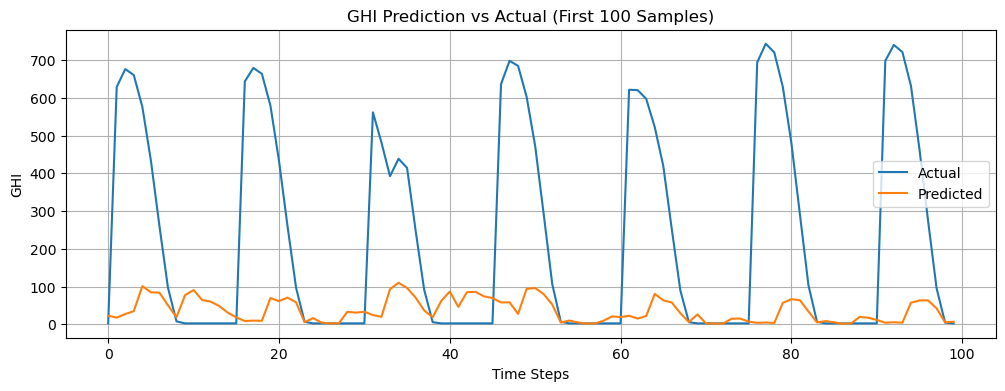

In [31]:
# 📉 Plot
plt.figure(figsize=(12, 4))
plt.plot(y_test_actual[:100], label='Actual')
plt.plot(y_pred_actual[:100], label='Predicted')
plt.legend()
plt.title("GHI Prediction vs Actual (First 100 Samples)")
plt.xlabel("Time Steps")
plt.ylabel("GHI")
plt.grid(True)
plt.show()

In [32]:
from datetime import datetime
# Given JSON data
json_data =  {
            "air_temp": 25,
            "ghi": 0,
            "gti": 0,
            "relative_humidity": 54.3,
            "wind_direction_10m": 44,
            "wind_speed_10m": 2.6,
            "period_end": "2025-03-24T14:10:00+00:00",
            "period": "PT10M"
        }

# Extracting datetime information
timestamp = datetime.fromisoformat(json_data["period_end"])  # Removing timezone

hour = timestamp.hour
day_of_year = timestamp.timetuple().tm_yday
day_of_week = timestamp.weekday()  # Monday=0, Sunday=6
month = timestamp.month 
is_weekend = 1 if timestamp.weekday() in [5, 6, 7] else 0  # Saturday (5) or Sunday (6)

# Calculate cyclic features
sin_hour = np.sin(2 * np.pi * hour / 24)
cos_hour = np.cos(2 * np.pi * hour / 24)

sin_day = np.sin(2 * np.pi * day_of_year / 365)
cos_day = np.cos(2 * np.pi * day_of_year / 365)

sin_dayofweek = np.sin(2 * np.pi * day_of_week / 7)
cos_dayofweek = np.cos(2 * np.pi * day_of_week / 7)

sin_month = np.sin(2 * np.pi * month / 12)
cos_month = np.cos(2 * np.pi * month / 12)

# Creating the NumPy array with all features
test_data = np.array([[
    json_data["air_temp"],
    json_data["gti"],
    json_data["relative_humidity"],
    json_data["wind_direction_10m"],
    json_data["wind_speed_10m"],
    is_weekend,
    sin_hour, cos_hour,
    sin_day, cos_day,
    sin_dayofweek, cos_dayofweek,
    sin_month, cos_month
]])

# Print the NumPy array
print(test_data)


[[ 2.50000000e+01  0.00000000e+00  5.43000000e+01  4.40000000e+01
   2.60000000e+00  0.00000000e+00 -5.00000000e-01 -8.66025404e-01
   9.89932495e-01  1.41540295e-01  0.00000000e+00  1.00000000e+00
   1.00000000e+00  6.12323400e-17]]


In [33]:
custom_data = np.array([
    [33, 891, 27.5, 99, 1, 0, 0.707, -0.707, -0.989, 0.14, 0, 1, 1, 0],  # t-5
    [32, 707, 28.3, 77, 1.1, 0, 0.5, -0.866, 0.989, 0.141, 0, 1, 1, 0],  # t-4
    [32, 473, 29.4, 56, 1.4, 0, 0.258, -0.966, 0.989, 0.14, 0, 1, 1, 0],  # t-3
    [31, 221, 35.8, 47, 1.3, 0, 0, -1, 0.989, 0.14, 0, 1, 1, 0],  # t-2
    [29, 11, 43.5, 40, 2.8, 0, -0.26, -0.966, 0.989, 0.14, 0, 1, 1, 0],  # t-1
    [25, 0, 54.3, 44, 2.6, 0, -0.5, -0.866, 0.989, 0.141, 0, 1, 1, 0],  # t (latest)
])

In [34]:
# scaled_custom = minmax.transform(custom_data)
scaled_custom = custom_data.reshape(1, 6, 14)


In [35]:
predicted_ghi_scaled = model.predict(scaled_custom)

InvalidArgumentError: Graph execution error:

Detected at node sequential_1/lstm_1/while/body/_1/sequential_1/lstm_1/while/lstm_cell_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [1,14], In[1]: [13,256]
	 [[{{node sequential_1/lstm_1/while/body/_1/sequential_1/lstm_1/while/lstm_cell_1/MatMul}}]] [Op:__inference_one_step_on_data_distributed_15032]

In [45]:
# Append dummy values to match shape
dummy = np.zeros((1, 14))
dummy[0, -1] = predicted_ghi_scaled  # Assuming GHI is last feature

predicted_ghi = scaler.inverse_transform(dummy)[0, -1]
print("Predicted GHI:", predicted_ghi)


Predicted GHI: 31.718965631415593


C:\Users\MD102894\AppData\Local\Temp\ipykernel_11684\1785332856.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dummy[0, -1] = predicted_ghi_scaled  # Assuming GHI is last feature


# XGBoost for Hourly data - Scaling

In [298]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib


# Load your data (replace with your actual file)
df = pd.read_csv(r"Solcast\SDPIPL_WTHR_2024_Hour.csv")

df['period_end'] = pd.to_datetime(df['period_end'])

df.head(10)

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,period_end,period
0,10,0,0,92.5,77,1.8,2024-01-01 01:00:00+00:00,PT60M
1,9,0,0,93.5,76,1.8,2024-01-01 02:00:00+00:00,PT60M
2,10,23,22,93.5,75,1.6,2024-01-01 03:00:00+00:00,PT60M
3,10,68,66,88.6,76,1.2,2024-01-01 04:00:00+00:00,PT60M
4,11,107,104,80.2,81,1.4,2024-01-01 05:00:00+00:00,PT60M
5,11,135,131,77.5,92,1.7,2024-01-01 06:00:00+00:00,PT60M
6,11,142,137,80.4,104,1.5,2024-01-01 07:00:00+00:00,PT60M
7,12,146,141,79.1,105,1.1,2024-01-01 08:00:00+00:00,PT60M
8,12,148,143,76.0,90,0.9,2024-01-01 09:00:00+00:00,PT60M
9,12,132,128,77.6,47,1.0,2024-01-01 10:00:00+00:00,PT60M


In [299]:
# --- Feature Engineering ---

df['hour'] = df['period_end'].dt.hour
df['day'] = df['period_end'].dt.day
df['month'] = df['period_end'].dt.month
df['weekday'] = df['period_end'].dt.weekday

In [300]:
df.query('hour >= 6 and hour <= 20', inplace=True)
# df.head(10)

In [301]:
# Targets
df['ghi_t+1'] = df['ghi'].shift(-1)
# df['ghi_t+2'] = df['ghi'].shift(-2)
# df['ghi_t+3'] = df['ghi'].shift(-3)

df.head(10)

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,period_end,period,hour,day,month,weekday,ghi_t+1
5,11,135,131,77.5,92,1.7,2024-01-01 06:00:00+00:00,PT60M,6,1,1,0,142.0
6,11,142,137,80.4,104,1.5,2024-01-01 07:00:00+00:00,PT60M,7,1,1,0,146.0
7,12,146,141,79.1,105,1.1,2024-01-01 08:00:00+00:00,PT60M,8,1,1,0,148.0
8,12,148,143,76.0,90,0.9,2024-01-01 09:00:00+00:00,PT60M,9,1,1,0,132.0
9,12,132,128,77.6,47,1.0,2024-01-01 10:00:00+00:00,PT60M,10,1,1,0,95.0
10,12,95,92,79.8,24,1.5,2024-01-01 11:00:00+00:00,PT60M,11,1,1,0,41.0
11,13,41,40,77.7,24,1.6,2024-01-01 12:00:00+00:00,PT60M,12,1,1,0,0.0
12,13,0,0,77.0,27,1.4,2024-01-01 13:00:00+00:00,PT60M,13,1,1,0,0.0
13,12,0,0,82.2,34,1.3,2024-01-01 14:00:00+00:00,PT60M,14,1,1,0,0.0
14,11,0,0,88.1,45,1.1,2024-01-01 15:00:00+00:00,PT60M,15,1,1,0,0.0


In [302]:
df[['ghi_t+1']] = df[['ghi_t+1']].fillna(0)

In [303]:
df.isna().sum()

air_temp              0
ghi                   0
gti                   0
relative_humidity     0
wind_direction_10m    0
wind_speed_10m        0
period_end            0
period                0
hour                  0
day                   0
month                 0
weekday               0
ghi_t+1               0
dtype: int64

In [304]:
features = ['air_temp', 'gti', 'relative_humidity', 'wind_speed_10m', 'wind_direction_10m',
            'weekday', 'hour', 'month', 'day']

scaler = StandardScaler()

# --- Model Training Function ---
def train_model(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model = XGBRegressor()
    model.fit(X_train_scaled, y_train)

    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor())
    ])

    pipeline.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    print(f"\n{label} Predictions:")
    print(f"RMSE: {rmse:.2f}, R²: {r2:.4f}")
    return model, y_pred

# --- Training Each Model ---
X = df[features]

model_1hr, y_pred_1hr = train_model(X, df['ghi_t+1'], "1-Hour Ahead")
# model_2hr, y_pred_2hr = train_model(X, df['ghi_t+2'], "2-Hours Ahead")
# model_3hr, y_pred_3hr = train_model(X, df['ghi_t+3'], "3-Hours Ahead")



1-Hour Ahead Predictions:
RMSE: 75.59, R²: 0.8874


F:\PK103313\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [305]:
# # Custom data
# import pandas as pd
# from datetime import datetime, timedelta

# # Given JSON data
# json_data =  {
#             "air_temp": 21,
#             "ghi": 462,
#             "gti": 627,
#             "relative_humidity": 41.7,
#             "wind_direction_10m": 313,
#             "wind_speed_10m": 3.6,
#             "period_end": "2025-01-23T10:00:00+00:00",
#             "period": "PT60M"
#         }

# timestamp = datetime.fromisoformat(json_data["period_end"])

# # Extract time features
# hour = timestamp.hour
# day = timestamp.day
# month = timestamp.month
# weekday = timestamp.weekday()
# sin_hour = np.sin(2 * np.pi * hour / 24)
# cos_hour = np.cos(2 * np.pi * hour / 24)

# sin_month = np.sin(2 * np.pi * month / 12)
# cos_month = np.cos(2 * np.pi * month / 12)

# sin_day = np.sin(2 * np.pi * day / 31)
# cos_day = np.cos(2 * np.pi * day / 31)

# #Lag
# ghi_lag_1 = 568 
# # ghi_lag_2 = 617
# # ghi_lag_3 = 603


# # Build DataFrame
# # custom_data = pd.DataFrame([[
# #     json_data['air_temp'], json_data['gti'], json_data['relative_humidity'], json_data['wind_direction_10m'], json_data['wind_speed_10m'], 
# #     hour, day, month, weekday, sin_hour, cos_hour, ghi_lag_1, ghi_lag_2, ghi_lag_3]], columns=features)


# custom_data = pd.DataFrame([[
#     json_data['air_temp'], json_data['gti'], json_data['relative_humidity'], json_data['wind_direction_10m'], json_data['wind_speed_10m'], 
#     day, weekday, sin_hour, cos_hour, sin_month, cos_month, sin_day, cos_day, ghi_lag_1, ghi_lag_2, ghi_lag_3]], columns=features)

# custom_data_scaled = scaler.transform(custom_data)

# # Make predictions
# pred_1hr = model_1hr.predict(custom_data_scaled)[0]
# pred_2hr = model_2hr.predict(custom_data_scaled)[0]
# pred_3hr = model_3hr.predict(custom_data_scaled)[0]

# # Output
# print(f"🔮 Predicted GHI at {(timestamp + timedelta(hours=1)).time()}: {pred_1hr:.2f} W/m²")
# print(f"🔮 Predicted GHI at {(timestamp + timedelta(hours=2)).time()}: {pred_2hr:.2f} W/m²")
# print(f"🔮 Predicted GHI at {(timestamp + timedelta(hours=3)).time()}: {pred_3hr:.2f} W/m²")


In [306]:
# ---- CSV Prediction ------

df = pd.read_csv(r"Solcast\Testing.csv")
df['period_end'] = pd.to_datetime(df['period_end'])

df['hour'] = df['period_end'].dt.hour
df['day'] = df['period_end'].dt.day
df['month'] = df['period_end'].dt.month
df['weekday'] = df['period_end'].dt.weekday

target = df['ghi']

features = ['air_temp', 'gti', 'relative_humidity', 'wind_speed_10m', 'wind_direction_10m',
            'weekday', 'hour', 'month', 'day']

df = df[features]

df.fillna(0, inplace=True)

custom_data_scaled = scaler.transform(df)

# Make predictions
pred_1hr = model_1hr.predict(custom_data_scaled)
# pred_2hr = model_2hr.predict(custom_data_scaled)[0]
# pred_3hr = model_3hr.predict(custom_data_scaled)[0]

# custom_data_scaled
df['actual'] = target
df['pred'] = pred_1hr.reshape(-1,1)

# test.head()
df.head(20)

,air_temp,gti,relative_humidity,wind_speed_10m,wind_direction_10m,weekday,hour,month,day,actual,pred
0,34,734,25.3,2.2,199,4,6,5,3,736,782.727356
1,35,783,24.4,2.2,214,4,7,5,3,782,404.556671
2,36,374,22.7,2.2,230,4,8,5,3,386,312.861420
3,37,290,21.0,2.6,243,4,9,5,3,300,277.726257
4,36,265,22.1,2.6,256,4,10,5,3,274,181.162125
5,35,193,24.1,2.4,266,4,11,5,3,200,207.296326
6,35,191,25.8,1.9,269,4,12,5,3,198,67.927437
7,34,88,32.0,1.4,281,4,13,5,3,91,8.788565
8,33,9,36.3,1.1,314,4,14,5,3,9,-0.530107
9,31,0,34.3,1.2,18,4,15,5,3,0,-0.026840


In [288]:
# Save entire pipeline
joblib.dump(pipeline, 'xgb_1hr_scaled.joblib')

# Load later
# pipeline = joblib.load('xgb_pipeline.joblib')

['xgb_1hr_scaled.joblib']

# GHI + GHI_t+1

In [364]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# Load your data (replace with your actual file)
df = pd.read_csv(r"Solcast\SDPIPL_WTHR_2024_Hour.csv")

df['period_end'] = pd.to_datetime(df['period_end'])

df.head(10)

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,period_end,period
0,10,0,0,92.5,77,1.8,2024-01-01 01:00:00+00:00,PT60M
1,9,0,0,93.5,76,1.8,2024-01-01 02:00:00+00:00,PT60M
2,10,23,22,93.5,75,1.6,2024-01-01 03:00:00+00:00,PT60M
3,10,68,66,88.6,76,1.2,2024-01-01 04:00:00+00:00,PT60M
4,11,107,104,80.2,81,1.4,2024-01-01 05:00:00+00:00,PT60M
5,11,135,131,77.5,92,1.7,2024-01-01 06:00:00+00:00,PT60M
6,11,142,137,80.4,104,1.5,2024-01-01 07:00:00+00:00,PT60M
7,12,146,141,79.1,105,1.1,2024-01-01 08:00:00+00:00,PT60M
8,12,148,143,76.0,90,0.9,2024-01-01 09:00:00+00:00,PT60M
9,12,132,128,77.6,47,1.0,2024-01-01 10:00:00+00:00,PT60M


In [365]:
# --- Feature Engineering ---

df['hour'] = df['period_end'].dt.hour
df['day'] = df['period_end'].dt.day
df['month'] = df['period_end'].dt.month
df['year'] = df['period_end'].dt.year
df['weekday'] = df['period_end'].dt.weekday

# # Time-based sinusoidal features
# df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
# df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

# df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
# df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# df['sin_day'] = np.sin(2 * np.pi * df['day'] / 31)
# df['cos_day'] = np.cos(2 * np.pi * df['day'] / 31)

df.head()

,air_temp,ghi,gti,relative_humidity,wind_direction_10m,wind_speed_10m,period_end,period,hour,day,month,year,weekday
0,10,0,0,92.5,77,1.8,2024-01-01 01:00:00+00:00,PT60M,1,1,1,2024,0
1,9,0,0,93.5,76,1.8,2024-01-01 02:00:00+00:00,PT60M,2,1,1,2024,0
2,10,23,22,93.5,75,1.6,2024-01-01 03:00:00+00:00,PT60M,3,1,1,2024,0
3,10,68,66,88.6,76,1.2,2024-01-01 04:00:00+00:00,PT60M,4,1,1,2024,0
4,11,107,104,80.2,81,1.4,2024-01-01 05:00:00+00:00,PT60M,5,1,1,2024,0


In [366]:
df.query('hour >= 6 and hour <= 20', inplace=True)
# df.head(10)

In [367]:
# Lags
# df['ghi_t-1'] = df['ghi'].shift(1)
# df['ghi_t-24'] = df['ghi'].shift(24)

In [368]:
df['ghi_t+1'] = df['ghi'].shift(-1)   # For 1-hour ahead
# df['ghi_t+24'] = df['ghi'].shift(-24) # For 24-hours ahead
df.fillna(0, inplace=True)

In [369]:
df.isna().sum()

air_temp              0
ghi                   0
gti                   0
relative_humidity     0
wind_direction_10m    0
wind_speed_10m        0
period_end            0
period                0
hour                  0
day                   0
month                 0
year                  0
weekday               0
ghi_t+1               0
dtype: int64

In [370]:
df.columns

Index(['air_temp', 'ghi', 'gti', 'relative_humidity', 'wind_direction_10m',
       'wind_speed_10m', 'period_end', 'period', 'hour', 'day', 'month',
       'year', 'weekday', 'ghi_t+1'],
      dtype='object')

In [371]:
# df.dropna(subset=['ghi_t+1', 'ghi_t+24'], inplace=True)

features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'hour', 'day', 'month', 'year', 'weekday', 'ghi']

scaler = StandardScaler()

# --- Model Training Function ---
def train_xgb(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)
    
    model = XGBRegressor()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    model.fit(X_train_scaled, y_train)

    pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor())
    ])

    pipeline.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    print(f"RMSE: {rmse:.2f}, R²: {r2:.4f}")
    return model

# --- Training Each Model ---
X = df[features]
model_1hr = train_xgb(X, df['ghi_t+1'])
# model_24hr = train_xgb(X, df['ghi_t+24'], "24-hours ahead")

RMSE: 69.20, R²: 0.9056


F:\PK103313\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [372]:
# # Custom data
# import pandas as pd
# from datetime import datetime, timedelta

# # Given JSON data
# json_data =  {
#             "air_temp": 21,
#             "ghi": 462,
#             "gti": 627,
#             "relative_humidity": 41.7,
#             "wind_direction_10m": 313,
#             "wind_speed_10m": 3.6,
#             "period_end": "2025-01-23T10:00:00+00:00",
#             "period": "PT60M"
#         }

# timestamp = datetime.fromisoformat(json_data["period_end"])

# # Extract time features
# hour = timestamp.hour
# day = timestamp.day
# month = timestamp.month
# weekday = timestamp.weekday()
# sin_hour = np.sin(2 * np.pi * hour / 24)
# cos_hour = np.cos(2 * np.pi * hour / 24)

# sin_month = np.sin(2 * np.pi * month / 12)
# cos_month = np.cos(2 * np.pi * month / 12)

# sin_day = np.sin(2 * np.pi * day / 31)
# cos_day = np.cos(2 * np.pi * day / 31)

# #Lag
# ghi_lag_1 = 568 
# ghi_lag_24 = 433 

# # Build DataFrame
# # custom_data = pd.DataFrame([[
# #     json_data['air_temp'], json_data['gti'], json_data['relative_humidity'], json_data['wind_direction_10m'], json_data['wind_speed_10m'], 
# #     hour, day, month, weekday, ghi_lag_1, ghi_lag_24]], columns=features)


# custom_data = pd.DataFrame([[
#     json_data['air_temp'], json_data['gti'], json_data['relative_humidity'], json_data['wind_direction_10m'], json_data['wind_speed_10m'], 
#     weekday, sin_hour, cos_hour, sin_month, cos_month, sin_day, cos_day, ghi_lag_1, ghi_lag_24]], columns=features)

# custom_data_scaled = scaler.transform(custom_data)

# # Make predictions
# pred_1hr = model_1hr.predict(custom_data_scaled)[0]
# pred_24hr = model_24hr.predict(custom_data_scaled)[0]

# # Output
# print(f"🔮 Predicted GHI at {(timestamp + timedelta(hours=1)).time()}: {pred_1hr:.2f} W/m²")
# print(f"🔮 GHI Tomorrow at {(timestamp + timedelta(hours=25)).time()}: {pred_24hr:.2f} W/m²")


In [374]:
# ---- Scaled CSV Prediction ------

df = pd.read_csv(r"Solcast\Testing.csv")
df['period_end'] = pd.to_datetime(df['period_end'])

df['hour'] = df['period_end'].dt.hour
df['day'] = df['period_end'].dt.day
df['month'] = df['period_end'].dt.month
df['year'] = df['period_end'].dt.year
df['weekday'] = df['period_end'].dt.weekday

# Time-based sinusoidal features
# df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
# df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)

# df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
# df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)

# df['sin_day'] = np.sin(2 * np.pi * df['day'] / 31)
# df['cos_day'] = np.cos(2 * np.pi * df['day'] / 31)
df['ghi_t+1'] = df['ghi'].shift(-1)
target = df['ghi_t+1']

# Lags
# df['ghi_t-1'] = df['ghi'].shift(1)
# df['ghi_t-24'] = df['ghi'].shift(24)
# df['ghi_t-3'] = df['ghi'].shift(3)

features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'hour', 'day', 'month', 'year', 'weekday', 'ghi']


# features = [
#     'air_temp', 'gti', 'relative_humidity', 'wind_speed_10m', 'wind_direction_10m',
#     'weekday', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day', 'ghi_t-1']

df = df[features]

df.fillna(0, inplace=True)

custom_data_scaled = scaler.transform(df)

# Make predictions
pred_1hr = model_1hr.predict(custom_data_scaled)
# pred_2hr = model_2hr.predict(custom_data_scaled)[0]
# pred_3hr = model_3hr.predict(custom_data_scaled)[0]

# Output
# print(f"🔮 Predicted GHI at {(timestamp + timedelta(hours=1)).time()}: {pred_1hr:.2f} W/m²")
# print(f"🔮 Predicted GHI at {(timestamp + timedelta(hours=2)).time()}: {pred_2hr:.2f} W/m²")
# print(f"🔮 Predicted GHI at {(timestamp + timedelta(hours=3)).time()}: {pred_3hr:.2f} W/m²")

# custom_data_scaled
df['actual'] = target
df['pred'] = pred_1hr.reshape(-1,1)

# test.head()
df.head(20)

,air_temp,gti,relative_humidity,wind_direction_10m,wind_speed_10m,hour,day,month,year,weekday,ghi,actual,pred
0,34,734,25.3,199,2.2,6,3,5,2024,4,736,782.0,779.262390
1,35,783,24.4,214,2.2,7,3,5,2024,4,782,386.0,393.807281
2,36,374,22.7,230,2.2,8,3,5,2024,4,386,300.0,341.963074
3,37,290,21.0,243,2.6,9,3,5,2024,4,300,274.0,265.711456
4,36,265,22.1,256,2.6,10,3,5,2024,4,274,200.0,187.341644
5,35,193,24.1,266,2.4,11,3,5,2024,4,200,198.0,183.223938
6,35,191,25.8,269,1.9,12,3,5,2024,4,198,91.0,76.083214
7,34,88,32.0,281,1.4,13,3,5,2024,4,91,9.0,3.459373
8,33,9,36.3,314,1.1,14,3,5,2024,4,9,0.0,1.075630
9,31,0,34.3,18,1.2,15,3,5,2024,4,0,0.0,-1.651636


In [375]:
# Save entire pipeline
joblib.dump(pipeline, 'xgb_ghi_t+1.joblib')

# Load later
# pipeline = joblib.load('xgb_pipeline.joblib')

['xgb_ghi_t+1.joblib']

# Cyclic Encoding - 89% (Redundant)

In [391]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# --- Load and preprocess training data ---
train_df = pd.read_csv(r"Solcast/SDPIPL_WTHR_2024_Hour.csv")
train_df['period_end'] = pd.to_datetime(train_df['period_end'])
train_df = train_df.query('period_end.dt.hour >= 6 and period_end.dt.hour <= 20')

# Feature Engineering
train_df['hour'] = train_df['period_end'].dt.hour
train_df['day'] = train_df['period_end'].dt.day
train_df['month'] = train_df['period_end'].dt.month
train_df['year'] = train_df['period_end'].dt.year
train_df['weekday'] = train_df['period_end'].dt.weekday

# Add lag feature
train_df['ghi_t-1'] = train_df['ghi'].shift(1)

# Add cyclical encoding
train_df['sin_hour'] = np.sin(2 * np.pi * train_df['hour'] / 24)
train_df['cos_hour'] = np.cos(2 * np.pi * train_df['hour'] / 24)
train_df['sin_month'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['cos_month'] = np.cos(2 * np.pi * train_df['month'] / 12)
train_df['sin_day'] = np.sin(2 * np.pi * train_df['day'] / 31)
train_df['cos_day'] = np.cos(2 * np.pi * train_df['day'] / 31)

# Targets
train_df['ghi_t+1'] = train_df['ghi'].shift(-1)
train_df.fillna(0, inplace=True)

# Features
features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'hour', 'day', 'month', 'year', 'weekday',
            'ghi_t-1', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']

# Model Training
X = train_df[features]
y = train_df['ghi_t+1']
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBRegressor()
model.fit(X_train_scaled, y_train)

# Save pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('xgb', model)
])
# joblib.dump(pipeline, 'xgb_1hr_pipeline.joblib')

# Evaluation
y_pred = model.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
print(f"1-Hour Ahead Forecast:\nRMSE: {rmse:.2f}, R²: {r2:.4f}")

# --- Load and preprocess test data ---
test_df = pd.read_csv(r"Solcast/Testing.csv")
test_df['period_end'] = pd.to_datetime(test_df['period_end'])
test_df['hour'] = test_df['period_end'].dt.hour
test_df['day'] = test_df['period_end'].dt.day
test_df['month'] = test_df['period_end'].dt.month
test_df['year'] = test_df['period_end'].dt.year
test_df['weekday'] = test_df['period_end'].dt.weekday
test_df['ghi_t-1'] = test_df['ghi'].shift(1)

# Cyclical encodings
for col, mod in [('hour', 24), ('month', 12), ('day', 31)]:
    test_df[f'sin_{col}'] = np.sin(2 * np.pi * test_df[col] / mod)
    test_df[f'cos_{col}'] = np.cos(2 * np.pi * test_df[col] / mod)

test_df['ghi_t+1'] = test_df['ghi'].shift(-1)
target = test_df['ghi_t+1']
test_df.fillna(0, inplace=True)

X_custom = test_df[features]
# pipeline = joblib.load('xgb_1hr_pipeline.joblib')
test_df = test_df[features]
test_df['pred'] = pipeline.predict(X_custom)
test_df['actual'] = target

# Show sample
test_df.head(20)


1-Hour Ahead Forecast:
RMSE: 71.64, R²: 0.8989


F:\PK103313\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,air_temp,gti,relative_humidity,wind_direction_10m,wind_speed_10m,hour,day,month,year,weekday,ghi_t-1,sin_hour,cos_hour,sin_month,cos_month,sin_day,cos_day,pred,actual
0,34,734,25.3,199,2.2,6,3,5,2024,4,0.0,1.000000e+00,6.123234e-17,0.5,-0.866025,0.571268,0.820763,764.866760,782.0
1,35,783,24.4,214,2.2,7,3,5,2024,4,736.0,9.659258e-01,-2.588190e-01,0.5,-0.866025,0.571268,0.820763,423.213989,386.0
2,36,374,22.7,230,2.2,8,3,5,2024,4,782.0,8.660254e-01,-5.000000e-01,0.5,-0.866025,0.571268,0.820763,289.293640,300.0
3,37,290,21.0,243,2.6,9,3,5,2024,4,386.0,7.071068e-01,-7.071068e-01,0.5,-0.866025,0.571268,0.820763,272.474182,274.0
4,36,265,22.1,256,2.6,10,3,5,2024,4,300.0,5.000000e-01,-8.660254e-01,0.5,-0.866025,0.571268,0.820763,220.088287,200.0
5,35,193,24.1,266,2.4,11,3,5,2024,4,274.0,2.588190e-01,-9.659258e-01,0.5,-0.866025,0.571268,0.820763,194.352982,198.0
6,35,191,25.8,269,1.9,12,3,5,2024,4,200.0,1.224647e-16,-1.000000e+00,0.5,-0.866025,0.571268,0.820763,87.305565,91.0
7,34,88,32.0,281,1.4,13,3,5,2024,4,198.0,-2.588190e-01,-9.659258e-01,0.5,-0.866025,0.571268,0.820763,9.136335,9.0
8,33,9,36.3,314,1.1,14,3,5,2024,4,91.0,-5.000000e-01,-8.660254e-01,0.5,-0.866025,0.571268,0.820763,-2.092283,0.0
9,31,0,34.3,18,1.2,15,3,5,2024,4,9.0,-7.071068e-01,-7.071068e-01,0.5,-0.866025,0.571268,0.820763,1.130430,0.0


# Cyclic Encoding - 93%

In [397]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# --- Load and preprocess training data ---
train_df = pd.read_csv(r"Solcast/SDPIPL_WTHR_2024_Hour.csv")
train_df['period_end'] = pd.to_datetime(train_df['period_end'])
train_df = train_df.query('period_end.dt.hour >= 6 and period_end.dt.hour <= 20')

# Feature Engineering
train_df['hour'] = train_df['period_end'].dt.hour
train_df['day'] = train_df['period_end'].dt.day
train_df['month'] = train_df['period_end'].dt.month
train_df['year'] = train_df['period_end'].dt.year
train_df['weekday'] = train_df['period_end'].dt.weekday

# Add lag feature
train_df['ghi_t-1'] = train_df['ghi'].shift(1)

# Add cyclical encoding
train_df['sin_hour'] = np.sin(2 * np.pi * train_df['hour'] / 24)
train_df['cos_hour'] = np.cos(2 * np.pi * train_df['hour'] / 24)
train_df['sin_month'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['cos_month'] = np.cos(2 * np.pi * train_df['month'] / 12)
train_df['sin_day'] = np.sin(2 * np.pi * train_df['day'] / 31)
train_df['cos_day'] = np.cos(2 * np.pi * train_df['day'] / 31)

# Targets
train_df['ghi_t+1'] = train_df['ghi'].shift(-1)
train_df.fillna(0, inplace=True)

# Features
# drop 'hour', 'day', 'month' & year from features
features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'weekday',
            'ghi_t-1', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']


# Model Training
X = train_df[features]
y = train_df['ghi_t+1']
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBRegressor()
model.fit(X_train_scaled, y_train)

# Save pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('xgb', model)
])
# joblib.dump(pipeline, 'xgb_1hr_cyclic_93.joblib')

# Evaluation
y_pred = model.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
print(f"1-Hour Ahead Forecast:\nRMSE: {rmse:.2f}, R²: {r2:.4f}")

# --- Load and preprocess test data ---
test_df = pd.read_csv(r"Solcast/Testing.csv")
test_df['period_end'] = pd.to_datetime(test_df['period_end'])
test_df['hour'] = test_df['period_end'].dt.hour
test_df['day'] = test_df['period_end'].dt.day
test_df['month'] = test_df['period_end'].dt.month
test_df['year'] = test_df['period_end'].dt.year
test_df['weekday'] = test_df['period_end'].dt.weekday
test_df['ghi_t-1'] = test_df['ghi'].shift(1)

# Cyclical encodings
for col, mod in [('hour', 24), ('month', 12), ('day', 31)]:
    test_df[f'sin_{col}'] = np.sin(2 * np.pi * test_df[col] / mod)
    test_df[f'cos_{col}'] = np.cos(2 * np.pi * test_df[col] / mod)

test_df['ghi_t+1'] = test_df['ghi'].shift(-1)
target = test_df['ghi_t+1']
test_df.fillna(0, inplace=True)

X_custom = test_df[features]
pipeline = joblib.load('xgb_1hr_cyclic_93.joblib')
test_df = test_df[features]
test_df['pred'] = pipeline.predict(X_custom)
test_df['actual'] = target

# Show sample
print(features)
test_df.head(20)

1-Hour Ahead Forecast:
RMSE: 59.51, R²: 0.9302
['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m', 'wind_speed_10m', 'weekday', 'ghi_t-1', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']


F:\PK103313\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,air_temp,gti,relative_humidity,wind_direction_10m,wind_speed_10m,weekday,ghi_t-1,sin_hour,cos_hour,sin_month,cos_month,sin_day,cos_day,pred,actual
0,34,734,25.3,199,2.2,4,0.0,1.000000e+00,6.123234e-17,0.5,-0.866025,0.571268,0.820763,776.623047,782.0
1,35,783,24.4,214,2.2,4,736.0,9.659258e-01,-2.588190e-01,0.5,-0.866025,0.571268,0.820763,417.936707,386.0
2,36,374,22.7,230,2.2,4,782.0,8.660254e-01,-5.000000e-01,0.5,-0.866025,0.571268,0.820763,299.294403,300.0
3,37,290,21.0,243,2.6,4,386.0,7.071068e-01,-7.071068e-01,0.5,-0.866025,0.571268,0.820763,274.511719,274.0
4,36,265,22.1,256,2.6,4,300.0,5.000000e-01,-8.660254e-01,0.5,-0.866025,0.571268,0.820763,235.214813,200.0
5,35,193,24.1,266,2.4,4,274.0,2.588190e-01,-9.659258e-01,0.5,-0.866025,0.571268,0.820763,188.386978,198.0
6,35,191,25.8,269,1.9,4,200.0,1.224647e-16,-1.000000e+00,0.5,-0.866025,0.571268,0.820763,80.945480,91.0
7,34,88,32.0,281,1.4,4,198.0,-2.588190e-01,-9.659258e-01,0.5,-0.866025,0.571268,0.820763,3.415063,9.0
8,33,9,36.3,314,1.1,4,91.0,-5.000000e-01,-8.660254e-01,0.5,-0.866025,0.571268,0.820763,-1.322162,0.0
9,31,0,34.3,18,1.2,4,9.0,-7.071068e-01,-7.071068e-01,0.5,-0.866025,0.571268,0.820763,0.730700,0.0


# Cyclic - No GHI_t-1 - 92%

In [398]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

# --- Load and preprocess training data ---
train_df = pd.read_csv(r"Solcast/SDPIPL_WTHR_2024_Hour.csv")
train_df['period_end'] = pd.to_datetime(train_df['period_end'])
train_df = train_df.query('period_end.dt.hour >= 6 and period_end.dt.hour <= 20')

# Feature Engineering
train_df['hour'] = train_df['period_end'].dt.hour
train_df['day'] = train_df['period_end'].dt.day
train_df['month'] = train_df['period_end'].dt.month
train_df['year'] = train_df['period_end'].dt.year
train_df['weekday'] = train_df['period_end'].dt.weekday

# Add lag feature
train_df['ghi_t-1'] = train_df['ghi'].shift(1)

# Add cyclical encoding
train_df['sin_hour'] = np.sin(2 * np.pi * train_df['hour'] / 24)
train_df['cos_hour'] = np.cos(2 * np.pi * train_df['hour'] / 24)
train_df['sin_month'] = np.sin(2 * np.pi * train_df['month'] / 12)
train_df['cos_month'] = np.cos(2 * np.pi * train_df['month'] / 12)
train_df['sin_day'] = np.sin(2 * np.pi * train_df['day'] / 31)
train_df['cos_day'] = np.cos(2 * np.pi * train_df['day'] / 31)

# Targets
train_df['ghi_t+1'] = train_df['ghi'].shift(-1)
train_df.fillna(0, inplace=True)

# Features
# drop 'hour', 'day', 'month' & year from features
features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'weekday', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']


# Model Training
X = train_df[features]
y = train_df['ghi_t+1']
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = XGBRegressor()
model.fit(X_train_scaled, y_train)

# Save pipeline
pipeline = Pipeline([
    ('scaler', scaler),
    ('xgb', model)
])
# joblib.dump(pipeline, 'xgb_1hr_cyclic_92_no_t+1.joblib')

# Evaluation
y_pred = model.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)
print(f"1-Hour Ahead Forecast:\nRMSE: {rmse:.2f}, R²: {r2:.4f}")

# --- Load and preprocess test data ---
test_df = pd.read_csv(r"Solcast/Testing.csv")
test_df['period_end'] = pd.to_datetime(test_df['period_end'])
test_df['hour'] = test_df['period_end'].dt.hour
test_df['day'] = test_df['period_end'].dt.day
test_df['month'] = test_df['period_end'].dt.month
test_df['year'] = test_df['period_end'].dt.year
test_df['weekday'] = test_df['period_end'].dt.weekday
# test_df['ghi_t-1'] = test_df['ghi'].shift(1)

# Cyclical encodings
for col, mod in [('hour', 24), ('month', 12), ('day', 31)]:
    test_df[f'sin_{col}'] = np.sin(2 * np.pi * test_df[col] / mod)
    test_df[f'cos_{col}'] = np.cos(2 * np.pi * test_df[col] / mod)

test_df['ghi_t+1'] = test_df['ghi'].shift(-1)
target = test_df['ghi_t+1']
test_df.fillna(0, inplace=True)

X_custom = test_df[features]
pipeline = joblib.load('xgb_1hr_cyclic_92_no_t+1.joblib')
test_df = test_df[features]
test_df['pred'] = pipeline.predict(X_custom)
test_df['actual'] = target

# Show sample
print(features)
test_df.head(20)

1-Hour Ahead Forecast:
RMSE: 59.69, R²: 0.9298
['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m', 'wind_speed_10m', 'weekday', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']


F:\PK103313\Anaconda\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


,air_temp,gti,relative_humidity,wind_direction_10m,wind_speed_10m,weekday,sin_hour,cos_hour,sin_month,cos_month,sin_day,cos_day,pred,actual
0,34,734,25.3,199,2.2,4,1.000000e+00,6.123234e-17,0.5,-0.866025,0.571268,0.820763,771.721802,782.0
1,35,783,24.4,214,2.2,4,9.659258e-01,-2.588190e-01,0.5,-0.866025,0.571268,0.820763,416.305817,386.0
2,36,374,22.7,230,2.2,4,8.660254e-01,-5.000000e-01,0.5,-0.866025,0.571268,0.820763,324.986572,300.0
3,37,290,21.0,243,2.6,4,7.071068e-01,-7.071068e-01,0.5,-0.866025,0.571268,0.820763,264.668610,274.0
4,36,265,22.1,256,2.6,4,5.000000e-01,-8.660254e-01,0.5,-0.866025,0.571268,0.820763,206.796799,200.0
5,35,193,24.1,266,2.4,4,2.588190e-01,-9.659258e-01,0.5,-0.866025,0.571268,0.820763,205.075821,198.0
6,35,191,25.8,269,1.9,4,1.224647e-16,-1.000000e+00,0.5,-0.866025,0.571268,0.820763,79.327126,91.0
7,34,88,32.0,281,1.4,4,-2.588190e-01,-9.659258e-01,0.5,-0.866025,0.571268,0.820763,4.869403,9.0
8,33,9,36.3,314,1.1,4,-5.000000e-01,-8.660254e-01,0.5,-0.866025,0.571268,0.820763,-3.804465,0.0
9,31,0,34.3,18,1.2,4,-7.071068e-01,-7.071068e-01,0.5,-0.866025,0.571268,0.820763,-4.055951,0.0


# Forecasting Other parameters

In [ ]:
# 

# ARIMA

In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'weekday', 'sin_hour', 'cos_hour', 'sin_month', 'cos_month', 'sin_day', 'cos_day']

model = SARIMAX(train_df['ghi'], 
                exog=train_df[features], 
                order=(2,1,2), 
                seasonal_order=(1,1,1,24))

results = model.fit()
forecast = results.forecast(steps=24, exog=test_df[features])

F:\PK103313\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
F:\PK103313\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Actual GHI values for comparison (shifted to match the forecast window)
actual = test_df['ghi'].iloc[:24].values

# Metrics
rmse = mean_squared_error(actual, forecast, squared=False)
mae = mean_absolute_error(actual, forecast)
r2 = r2_score(actual, forecast)

print(f"24-Hour Forecast Evaluation:")
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(actual, label='Actual GHI', marker='o')
plt.plot(forecast, label='Predicted GHI', marker='x')
plt.title('SARIMAX 24-Hour GHI Forecast')
plt.xlabel('Hour')
plt.ylabel('GHI')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# FNN

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

# 1. Load and preprocess
df = pd.read_csv("Solcast/SDPIPL_WTHR_2024_Hour.csv")
df['period_end'] = pd.to_datetime(df['period_end'])
df = df.query('period_end.dt.hour >= 6 and period_end.dt.hour <= 20')

# Feature engineering
df['hour'] = df['period_end'].dt.hour
df['day'] = df['period_end'].dt.day
df['month'] = df['period_end'].dt.month
df['year'] = df['period_end'].dt.year
df['weekday'] = df['period_end'].dt.weekday

# Lag and cyclical
df['ghi_t-1'] = df['ghi'].shift(1)
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
df['sin_day'] = np.sin(2 * np.pi * df['day'] / 31)
df['cos_day'] = np.cos(2 * np.pi * df['day'] / 31)
df['ghi_t+1'] = df['ghi'].shift(-1)

df.dropna(inplace=True)

# Feature selection
features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'ghi_t-1', 'sin_hour', 'cos_hour',
            'sin_month', 'cos_month', 'sin_day', 'cos_day']

X = df[features]
y = df['ghi_t+1']

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

# 2. Feedforward NN model
model = Sequential([
    Dense(128, input_dim=X_train.shape[1], activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

# 3. Training
history = model.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=16, verbose=1)

# 4. Evaluation
loss, mae = model.evaluate(X_test, y_test)
print(f"\nTest MAE: {mae:.2f}")

# Optional: Save model
# model.save("mlp_ghi_forecast.h5")


F:\PK103313\Anaconda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.0432 - loss: 135359.4375 - val_accuracy: 0.0000e+00 - val_loss: 18821.4941
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0481 - loss: 18711.1426 - val_accuracy: 0.3212 - val_loss: 16196.3740
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2488 - loss: 16717.2949 - val_accuracy: 0.3371 - val_loss: 12475.7275
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3059 - loss: 12422.2764 - val_accuracy: 0.3303 - val_loss: 10238.3398
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3552 - loss: 10511.7100 - val_accuracy: 0.3690 - val_loss: 8609.3516
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3647 - loss: 8168.2549 - val_accuracy: 0.3667 - val_loss: 6899.6211
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3595 - loss: 6884.0308 - val_accuracy: 0.3850 - val_loss: 4872.5205
Epoch 8/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/s

In [42]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Load and preprocess
df = pd.read_csv("Solcast/SDPIPL_WTHR_2024_Hour.csv")
df['period_end'] = pd.to_datetime(df['period_end'])
df = df.query('period_end.dt.hour >= 6 and period_end.dt.hour <= 20')

# Feature engineering
df['hour'] = df['period_end'].dt.hour
df['day'] = df['period_end'].dt.day
df['month'] = df['period_end'].dt.month
df['year'] = df['period_end'].dt.year
df['weekday'] = df['period_end'].dt.weekday

# Lag and cyclical
df['ghi_t-1'] = df['ghi'].shift(1)
df['sin_hour'] = np.sin(2 * np.pi * df['hour'] / 24)
df['cos_hour'] = np.cos(2 * np.pi * df['hour'] / 24)
df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
df['sin_day'] = np.sin(2 * np.pi * df['day'] / 31)
df['cos_day'] = np.cos(2 * np.pi * df['day'] / 31)
df['ghi_t+1'] = df['ghi'].shift(-1)

df.dropna(inplace=True)

# Feature columns
features = ['air_temp', 'gti', 'relative_humidity', 'wind_direction_10m',
            'wind_speed_10m', 'ghi_t-1', 'sin_hour', 'cos_hour',
            'sin_month', 'cos_month', 'sin_day', 'cos_day']

X = df[features]
y = df['ghi_t+1']

# Scale and reshape for CNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# CNN expects 3D input: (samples, timesteps, features)
X_reshaped = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))

# Split
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, shuffle=False)

# CNN Model
model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.2),
    Conv1D(filters=32, kernel_size=2, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])

# Train
history = model.fit(X_train, y_train, validation_split=0.1, epochs=50, batch_size=16, verbose=1)

# Evaluate
loss, mae = model.evaluate(X_test, y_test)
print(f"\nTest MAE: {mae:.2f}")

# Save model (optional)
# model.save("cnn_ghi_forecast.h5")


F:\PK103313\Anaconda\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.0408 - loss: 128739.5078 - val_accuracy: 0.0000e+00 - val_loss: 40191.0234
Epoch 2/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0207 - loss: 38545.3242 - val_accuracy: 0.2460 - val_loss: 15009.4561
Epoch 3/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1824 - loss: 21031.3516 - val_accuracy: 0.2483 - val_loss: 12428.3271
Epoch 4/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1907 - loss: 17215.6641 - val_accuracy: 0.2255 - val_loss: 11535.1650
Epoch 5/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1691 - loss: 16099.8076 - val_accuracy: 0.2187 - val_loss: 10214.1729
Epoch 6/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1784 - loss: 14759.3945 - val_accuracy: 0.2415 - val_loss: 10062.4873
Epoch 7/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1821 - loss: 14381.4375 - val_accuracy: 0.2574 - val_loss: 8955.7646
Epoch 8/50
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 